# **Проект по компьютерному зрению**

In [ ]:
! pip install -r requirements.txt

In [ ]:
# import kagglehub
# 
# # kaggle_api = KGAT_8eb0727ee6d566add6db98054cc75b1f
# kagglehub.login()

In [ ]:
# kagglehub.competition_download(
#     "ml-intensive-yandex-academy-spring-2026",
#     output_dir="./data"
# )

# **IMPORTS MODULE**

In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch import nn
import torch.optim as optim
from torchsummary import summary
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import transforms 
import matplotlib.pyplot as plt
from IPython.display import clear_output

# **DATASET MODULE**

In [ ]:
class CustomDataset(Dataset):
    def __init__(
            self,
            img_dir: str,
            _train: bool = True,
            csv_path: str = None,
            _transform: transforms.Compose = None
    ):
        self.img_dir = img_dir
        self.train = _train
        self.data = pd.read_csv(
            csv_path, names=["id", "label"]
        ) if _train else None
        self._transform = _transform
    
    def __len__(self):
        return len(os.listdir(
            os.path.abspath(self.img_dir))
        )
    
    def __getitem__(
            self,
            idx: int
    ):
        if self.train:
            label = torch.tensor(
                self.data.iloc[idx]["label"],
                dtype=torch.float32
            )  
        else:
            label = idx
            
        path = os.path.join(self.img_dir, f"{idx}.jpg")
        img = Image.open(path).convert("RGB")
        if self._transform:
            img = self._transform(img)
            
        return img, label

# **PARAMS MODULE**

In [38]:
IMAGE_SIZE = (256, 256)

BATCH_SIZE = 128

LEARNING_RATE = 0.01

criterion = nn.BCEWithLogitsLoss()

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

SOLUTION_FILE_PATH = "./data/dataset/train_solution.csv"
TRAIN_IMAGES_DIR = "./data/dataset/train_images"
MODEL_WEIGHTS_PATH = "./weights/model_weights.pth"
TEST_IMAGES_DIR = "./data/dataset/test_images"

# **DATALOAD MODULE**

In [28]:
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    # Сюда добавить аугментации
    transforms.ToTensor()
])

dataset = CustomDataset(
    img_dir=TRAIN_IMAGES_DIR,
    csv_path=SOLUTION_FILE_PATH,
    _train=True,
    _transform=transform
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# **IMAGES MODULE**

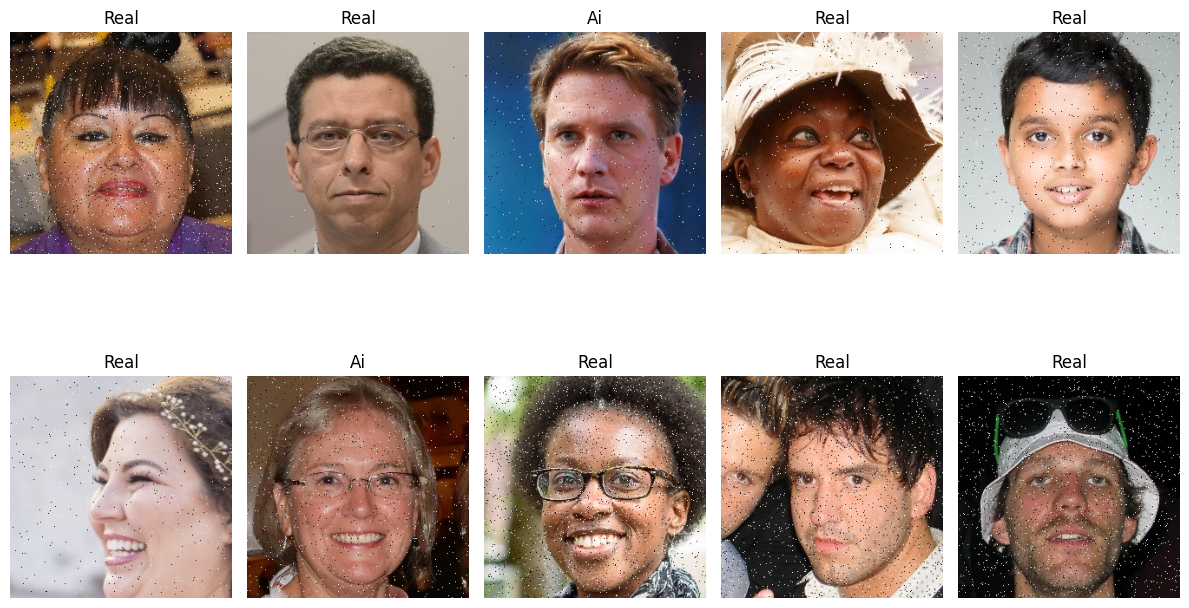

In [29]:
to_pil = transforms.ToPILImage()


def show_image(img):
    image = to_pil(img)
    plt.imshow(image)
    plt.axis("off")


dataiter = iter(train_loader)
_images, _labels = next(dataiter)

plt.figure(figsize=(12, 8))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    show_image(_images[i])
    plt.title("Real" if _labels[i].item() == 0 else "Ai")
    
plt.tight_layout()
plt.show()

# **MODEL MODULE**

In [30]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def show_summary(self):
        summary(self, input_size=(3, 256, 256))
        return

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# **MODEL**

In [31]:
MODEL = Model().to(DEVICE)
OPTIMIZER = optim.Adam(
    MODEL.parameters(),
    lr=LEARNING_RATE
)
MODEL

Model(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [32]:
MODEL.show_summary()

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 128, 128]             448
       BatchNorm2d-2         [-1, 16, 128, 128]              32
              ReLU-3         [-1, 16, 128, 128]               0
            Conv2d-4           [-1, 32, 64, 64]           4,640
       BatchNorm2d-5           [-1, 32, 64, 64]              64
              ReLU-6           [-1, 32, 64, 64]               0
            Conv2d-7           [-1, 64, 32, 32]          18,496
       BatchNorm2d-8           [-1, 64, 32, 32]             128
              ReLU-9           [-1, 64, 32, 32]               0
           Conv2d-10          [-1, 128, 16, 16]          73,856
      BatchNorm2d-11          [-1, 128, 16, 16]             256
             ReLU-12          [-1, 128, 16, 16]               0
          Flatten-13                [-1, 32768]               0
           Linear-14                  [

In [33]:
def show_losses(
        train_loss_hist,
        train_accs_hist,
        val_loss_hist,
        val_accs_hist
):
    clear_output()

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_loss_hist, label="Train loss")
    plt.plot(val_loss_hist, label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss curves")

    plt.subplot(1, 2, 2)
    plt.plot(train_accs_hist, label="Train acc")
    plt.plot(val_accs_hist, label="Val acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Accuracy curves")

    plt.tight_layout()
    plt.show()

# **TRAIN MODULE**

In [ ]:
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    
    for image, labels in loader:
        image, labels = image.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
        outputs = model(image)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        probs = torch.sigmoid(outputs)
        
        predictions = (probs > 0.5).int()
        correct += (predictions == labels).sum().item()
        
    avg_loss = total_loss / len(loader)
    accuracy = correct / len(loader.dataset)
    return avg_loss, accuracy


@torch.inference_mode()  # torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    correct = 0
    
    for image, labels in loader:
        image, labels = image.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
        outputs = model(image)
        loss = criterion(outputs, labels)
        
        total_loss += loss.item()
        probs = torch.sigmoid(outputs)
        
        predictions = (probs > 0.5).int()
        correct += (predictions == labels).sum().item()
        
    avg_loss = total_loss / len(loader)
    accuracy = correct / len(loader.dataset)
    
    return avg_loss, accuracy

# **RUN_TRAINING MODULE**

In [ ]:
def run(
        model,
        _train_loader,
        _val_loader,
        optimizer,
        epochs: int = 10
):
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(
            model,
            _train_loader,
            optimizer
        )
        val_loss, val_acc = evaluate(
            model,
            _val_loader
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        show_losses(
            train_loss_hist=train_losses,
            train_accs_hist=train_accs,
            val_loss_hist=val_losses,
            val_accs_hist=val_accs
        )
        print(f"Epoch {epoch + 1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
        
    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs
    }

# **TRAINING**

In [ ]:
history_data = train(
    model=MODEL,
    _train_loader=train_loader,
    _val_loader=val_loader,
    optimizer=OPTIMIZER,
    epochs=50
)

# **SAVING MODEL WEIGHTS**

In [39]:
torch.save(MODEL.state_dict(), MODEL_WEIGHTS_PATH)

# **LOADING MODEL WEIGHTS**

In [ ]:
MODEL.load_state_dict(torch.load(MODEL_WEIGHTS_PATH))

# **TEST_DATASET MODULE**

In [ ]:
test_dataset = CustomDataset(
    img_dir=TEST_IMAGES_DIR,
    _train=False,
    _transform=transform
)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# **PREDICT MODULE**

In [ ]:
@torch.inference_mode() # torch.no_grad()
def predict(model, _test_loader):
    model.eval()

    predictions = []

    for images, images_ids in _test_loader:
        images = images.to(DEVICE)

        outputs = model(images)
        probs = outputs.squeeze()

        predictions = (probs > 0.5).int().cpu().numpy()        
        for img_id, pred in zip(images_ids, predictions):
            predictions.append((img_id.item(), pred))

    return predictions

# **PREDICT**

In [ ]:
y = predict(MODEL, test_loader)
df = pd.DataFrame(y, columns=["id", "label"])
df = df.sort_values("id")
df